# Aula 4 — XOR com rede neural (MLP)

Treinamento com SGD e visualização da **perda (loss)** ao longo das épocas.

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Modelo da nossa rede (mesmo dos slides anteriores)
modelo = nn.Sequential(
    nn.Linear(2, 5),   # W^(1) e b^(1)
    nn.Sigmoid(),      # σ(W^(1)x + b^(1))
    nn.Linear(5, 1),   # w^(2) e b^(2)
    nn.Sigmoid()       # σ(w^(2)h + b^(2))
)

# Otimizador: quem vai executar w_novo = w_antigo - η * ∂L/∂w
optimizer = torch.optim.SGD(modelo.parameters(), lr=0.1)

# Dados (XOR)
X = torch.tensor([[0.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0],
                  [1.0, 1.0]])

y = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

In [ ]:
num_epochs = 1000
loss_history = []
epoch_indices = []

for epoch in range(num_epochs):
    y_hat = modelo(X)
    loss = ((y - y_hat) ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    epoch_indices.append(epoch)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

Epoch    0 | Loss: 0.250751
Epoch  100 | Loss: 0.250417
Epoch  200 | Loss: 0.250384
Epoch  300 | Loss: 0.250355
Epoch  400 | Loss: 0.250329
Epoch  500 | Loss: 0.250305
Epoch  600 | Loss: 0.250283
Epoch  700 | Loss: 0.250262
Epoch  800 | Loss: 0.250244
Epoch  900 | Loss: 0.250227


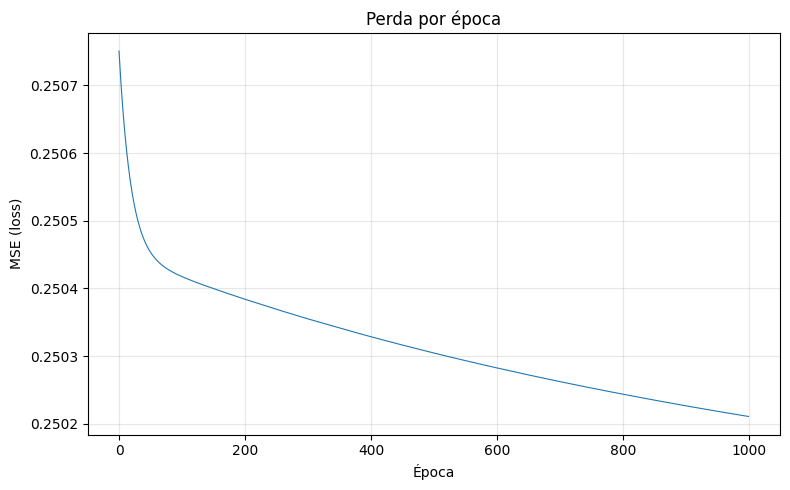

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Curva de perda (loss) ao longo do treino
ax.plot(epoch_indices, loss_history, color="tab:blue", linewidth=0.8)
ax.set_xlabel("Época")
ax.set_ylabel("MSE (loss)")
ax.set_title("Perda por época")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()